In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.spatial.distance import cdist


def sg_jacobian_projection(x: np.ndarray, y: np.ndarray, window_length: int = 151):
    """
    Aplica un filtro de Savitzky-Golay mediante proyección Jacobiana
    sobre una señal 1D, ajustando un polinomio cuadrático en ventanas deslizantes.

    Parámetros:
        x (np.ndarray): Vector de posiciones (eje x).
        y (np.ndarray): Vector de valores de la señal (eje y), del mismo tamaño que x.
        window_length (int): Longitud de la ventana (debe ser impar).

    Retorna:
        x_valid (np.ndarray): Puntos x donde la aproximación es válida.
        a_vals (np.ndarray): Coeficientes cuadráticos (curvatura).
        b_vals (np.ndarray): Coeficientes lineales (pendiente).
        c_vals (np.ndarray): Coeficientes constantes (offset).
    """
    assert window_length % 2 == 1, "window_length debe ser impar"
    assert len(x) == len(y), "x e y deben tener la misma longitud"

    dx = x[1] - x[0]
    half_win = window_length // 2
    x_local = np.arange(-half_win, half_win + 1) * dx

    # Matriz de diseño del Jacobiano
    J = np.vstack([x_local**2, x_local, np.ones_like(x_local)]).T
    JTJ_inv = np.linalg.inv(J.T @ J)
    J_pinv = JTJ_inv @ J.T

    # Aplicar proyección local
    a_vals, b_vals, c_vals = [], [], []
    for i in range(half_win, len(x) - half_win):
        y_window = y[i - half_win:i + half_win + 1]
        beta = J_pinv @ y_window
        a_vals.append(beta[0])
        b_vals.append(beta[1])
        c_vals.append(beta[2])

    x_valid = x[half_win: -half_win]
    return (
        np.asarray(x_valid),
        np.asarray(a_vals).ravel(),
        np.asarray(b_vals).ravel(),
        np.asarray(c_vals).ravel()
    )

Text(0.5, 0, 'Pixel number')

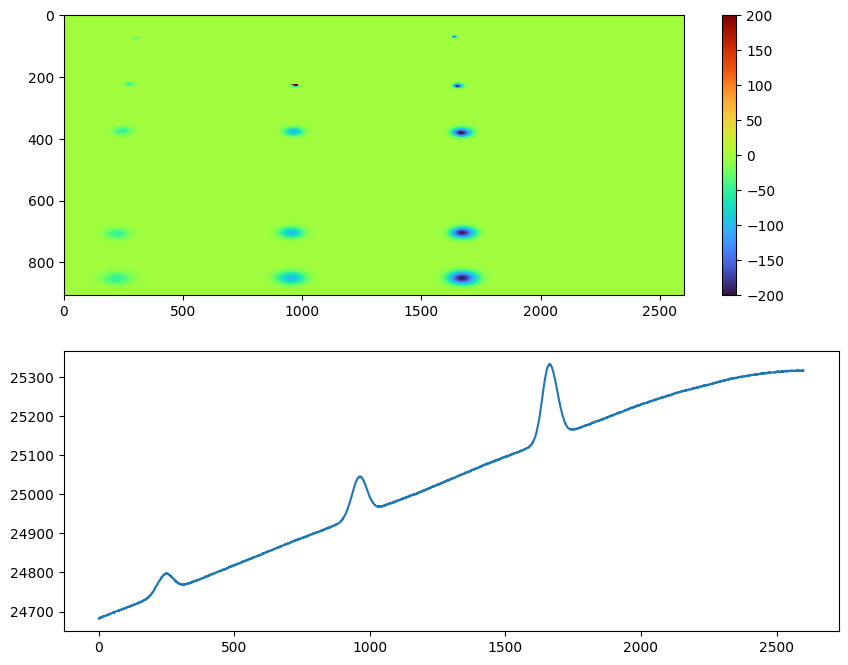

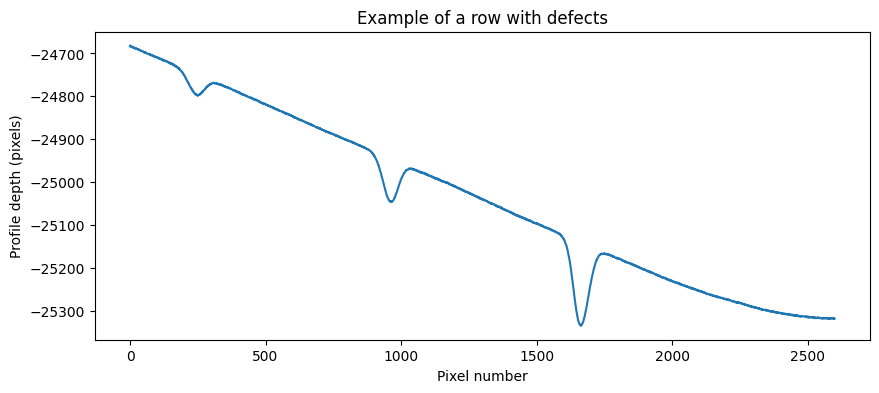

In [32]:
# %matplotlib qt

import camera.raw as raw
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.signal import savgol_filter

dist = raw.read_img_raw(f"defectos_simulados/experimento1/escaneo/step_00_orig_perlin.raw")
dist = dist[:907, 900:3500]

ground_truth = raw.read_img_raw(f"defectos_simulados/experimento1/escaneo_limpio/step_00_orig.raw")
ground_truth = ground_truth[:907, 900:3500]

# Initialize ground_truth with same shape as dist
# ground_truth = np.zeros_like(dist)

# # Apply Savitzky-Golay filter to each row
# for i in range(dist.shape[0]):
#     ground_truth[i, :, 0] = savgol_filter(dist[i, :, 0], window_length=301, polyorder=1)

defects = ground_truth - dist


# Configura la figura para mostrar la imagen del canal 0 y el gráfico de la primera fila
plt.close()
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(10, 8))  # Dos subgráficos, uno para la imagen y otro para el gráfico

# Muestra la imagen del canal 0
im = ax1.imshow(defects, aspect='auto',vmin=-200, vmax=200, cmap='turbo')
cbar = fig.colorbar(im, ax=ax1)

ax2.plot(dist[380, :])
# ax3.plot(dist[77, :])

plt.figure(figsize=(10, 4))
plt.plot(-dist[380, :])
plt.title("Example of a row with defects")
plt.ylabel("Profile depth (pixels)")
plt.xlabel("Pixel number")

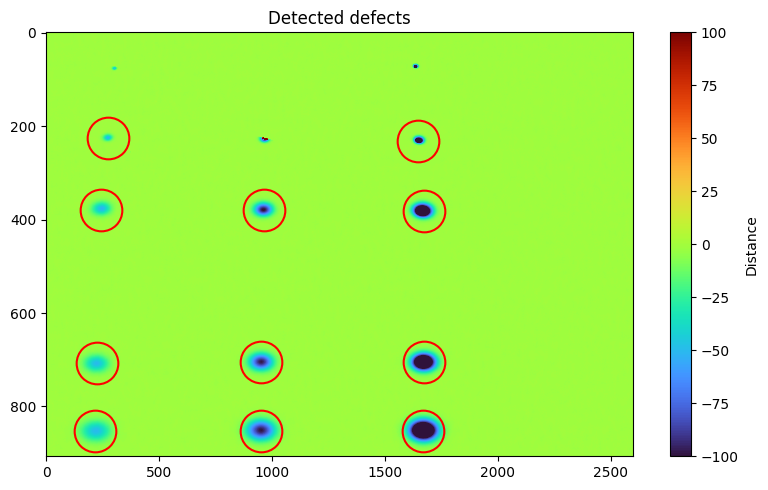

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.close("all")

# Leer el archivo con coordenadas (omitiendo líneas con '#')
defect_coords = np.loadtxt("defectos_simulados/experimento1/defects.txt", comments="#")

# Si hay solo un punto, forzamos a que sea 2D
if defect_coords.ndim == 1:
    defect_coords = defect_coords[np.newaxis, :]

# Mostrar la imagen
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(defects, aspect='auto',vmin=-100, vmax=100, cmap='turbo')
fig.colorbar(im, ax=ax, label="Distance")

# Marcar los defectos con círculos rojos
for (x, y, w, d) in defect_coords:
    ax.plot(x, y, 'ro', markersize=30, markerfacecolor='none', markeredgewidth=1.5)

ax.set_title("Detected defects")
plt.tight_layout()
plt.show()


Probamos sobre un perfil con defecto.

Elegimos el defecto concreto

   curvature_peak   a (Jacobian)  b (Jacobian)    vertex  x_target (from file)
0         0.36591  232275.338402    -13.480721  0.365939              0.366679


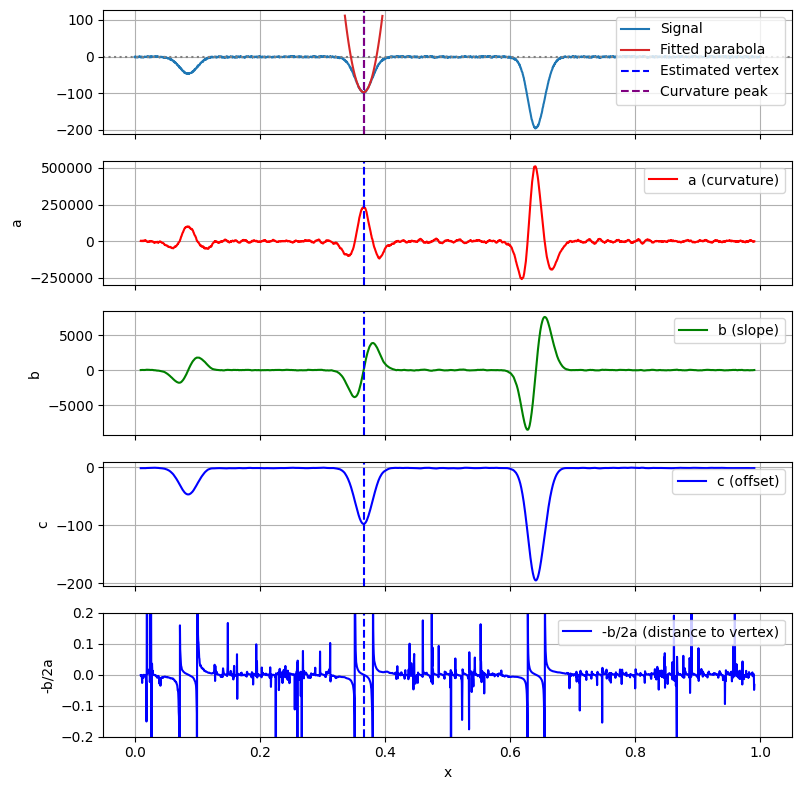

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ============================================
# Parámetro de entrada: índice del defecto (0 a N-1)
# ============================================
defecto_idx = 6

# ============================================
# Cargar coordenadas desde archivo
# ============================================
defect_coords = np.loadtxt("defectos_simulados/experimento1/defects.txt", comments="#")
if defect_coords.ndim == 1:
    defect_coords = defect_coords[np.newaxis, :]
x_px, y_px = defect_coords[defecto_idx, :2].astype(int)

# ============================================
# Extraer perfil horizontal desde imagen
# ============================================
perfil = defects[y_px, :]
x = np.linspace(0, 1, len(perfil))
x_target = x[x_px]  # coordenada normalizada del defecto

# ============================================
# SG projection
# ============================================
x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x, perfil, window_length=51)
a_vals = np.ravel(a_vals)
b_vals = np.ravel(b_vals)
c_vals = np.ravel(c_vals)

# ============================================
# Detección de picos de curvatura
# ============================================
curv_threshold = 20000
min_prominence = 100
min_distance = 100

peaks_indices, _ = find_peaks(
    a_vals,
    height=curv_threshold / 2,
    prominence=min_prominence / 2,
    distance=min_distance,
    width=3
)
x_peaks = x_valid[peaks_indices]
a_peaks = a_vals[peaks_indices]
b_peaks = b_vals[peaks_indices]
c_peaks = c_vals[peaks_indices]
vertices = x_peaks - b_peaks / (2 * a_peaks)

# ============================================
# Elegir el vértice más cercano a la semilla
# ============================================
idx_closest = np.argmin(np.abs(vertices - x_target))
x_peak = x_peaks[idx_closest]
a_detected = np.array([a_peaks[idx_closest]])
b_detected = np.array([b_peaks[idx_closest]])
c_detected = np.array([c_peaks[idx_closest]])
vertex = vertices[idx_closest]

# ============================================
# Tabla de resultados
# ============================================
df = pd.DataFrame({
    "curvature_peak": [x_peak],
    "a (Jacobian)": a_detected,
    "b (Jacobian)": b_detected,
    "vertex": [vertex],
    "x_target (from file)": [x_target]
})
print(df.round(6))

# ============================================
# Plot combined figures
# ============================================
fig, axs = plt.subplots(5, 1, figsize=(8, 8), sharex=True)

# Plot perfil con parábola
axs[0].plot(x, perfil, label="Signal")
axs[0].axhline(0, color='gray', linestyle=':')

x_range = np.linspace(-0.03, 0.03, 100)
x_parab = vertex + x_range
y_parab = a_detected[0] * x_range**2 + b_detected[0] * x_range + c_detected[0]
axs[0].plot(x_parab, y_parab, color='tab:red', linewidth=1.5, label="Fitted parabola")

# Líneas verticales
axs[0].axvline(vertex, color='blue', linestyle='--', label="Estimated vertex")
axs[0].axvline(x_peak, color='purple', linestyle='--', label="Curvature peak")
axs[0].legend()
# axs[0].set_ylabel("Detrended signal")
axs[0].grid(True)

# Plot coefficients
axs[1].plot(x_valid, a_vals, label="a (curvature)", color='red')
axs[1].axvline(vertex, color='blue', linestyle='--')
axs[1].set_ylabel("a")
axs[1].legend()
axs[1].grid(True)

axs[2].plot(x_valid, b_vals, label="b (slope)", color='green')
axs[2].axvline(vertex, color='blue', linestyle='--')
axs[2].set_ylabel("b")
axs[2].legend()
axs[2].grid(True)

axs[3].plot(x_valid, c_vals, label="c (offset)", color='blue')
axs[3].axvline(vertex, color='blue', linestyle='--')
axs[3].set_ylabel("c")
axs[3].legend()
axs[3].grid(True)

axs[4].plot(x_valid, (-1*b_vals) / (2 * a_vals), label="-b/2a (distance to vertex)", color='blue')
axs[4].axvline(vertex, color='blue', linestyle='--')
axs[4].set_ylabel("-b/2a")
axs[4].set_ylim([-.2, .2])
axs[4].legend()
axs[4].grid(True)

plt.xlabel("x")
plt.tight_layout()
plt.show()


   curvature_peak   a (Jacobian)  b (Jacobian)    vertex  x_target (from file)
0        0.084648  110198.208808   -182.704761  0.085477              0.086572
   curvature_peak   a (Jacobian)  b (Jacobian)    vertex  x_target (from file)
0         0.36591  232275.338402    -13.480721  0.365939              0.366679
   curvature_peak   a (Jacobian)  b (Jacobian)    vertex  x_target (from file)
0        0.639861  515775.714731  -1426.590331  0.641244              0.643709


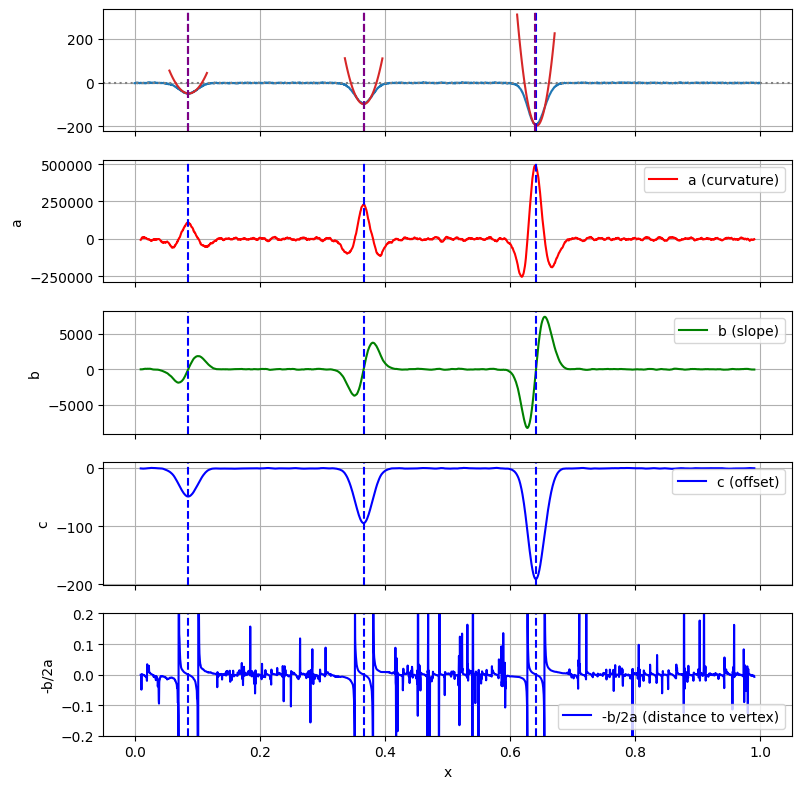

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ============================================
# Parámetro de entrada: índice del defecto (0 a N-1)
# ============================================
defecto_idx = 6
fig, axs = plt.subplots(5, 1, figsize=(8, 8), sharex=True)

first = True

for defecto_idx in [5,6,7]:
    # ============================================
    # Cargar coordenadas desde archivo
    # ============================================
    defect_coords = np.loadtxt("defectos_simulados/experimento1/defects.txt", comments="#")
    if defect_coords.ndim == 1:
        defect_coords = defect_coords[np.newaxis, :]
    x_px, y_px = defect_coords[defecto_idx, :2].astype(int)

    # ============================================
    # Extraer perfil horizontal desde imagen
    # ============================================
    perfil = defects[y_px, :]
    x = np.linspace(0, 1, len(perfil))
    x_target = x[x_px]  # coordenada normalizada del defecto

    # ============================================
    # SG projection
    # ============================================
    x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x, perfil, window_length=51)
    a_vals = np.ravel(a_vals)
    b_vals = np.ravel(b_vals)
    c_vals = np.ravel(c_vals)

    # ============================================
    # Detección de picos de curvatura
    # ============================================
    curv_threshold = 20000
    min_prominence = 100
    min_distance = 100

    peaks_indices, _ = find_peaks(
        a_vals,
        height=curv_threshold / 2,
        prominence=min_prominence / 2,
        distance=min_distance,
        width=3
    )
    x_peaks = x_valid[peaks_indices]
    a_peaks = a_vals[peaks_indices]
    b_peaks = b_vals[peaks_indices]
    c_peaks = c_vals[peaks_indices]
    vertices = x_peaks - b_peaks / (2 * a_peaks)

    # ============================================
    # Elegir el vértice más cercano a la semilla
    # ============================================
    idx_closest = np.argmin(np.abs(vertices - x_target))
    x_peak = x_peaks[idx_closest]
    a_detected = np.array([a_peaks[idx_closest]])
    b_detected = np.array([b_peaks[idx_closest]])
    c_detected = np.array([c_peaks[idx_closest]])
    vertex = vertices[idx_closest]

    # ============================================
    # Tabla de resultados
    # ============================================
    df = pd.DataFrame({
        "curvature_peak": [x_peak],
        "a (Jacobian)": a_detected,
        "b (Jacobian)": b_detected,
        "vertex": [vertex],
        "x_target (from file)": [x_target]
    })
    print(df.round(6))

    # ============================================
    # Plot combined figures
    # ============================================

    if first:
        # Plot perfil con parábola
        axs[0].plot(x, perfil, label="Signal")
        axs[0].axhline(0, color='gray', linestyle=':')

        x_range = np.linspace(-0.03, 0.03, 100)
        x_parab = vertex + x_range
        y_parab = a_detected[0] * x_range**2 + b_detected[0] * x_range + c_detected[0]
        axs[0].plot(x_parab, y_parab, color='tab:red', linewidth=1.5, label="Fitted parabola")

        # Líneas verticales
        axs[0].axvline(vertex, color='blue', linestyle='--', label="Estimated vertex")
        axs[0].axvline(x_peak, color='purple', linestyle='--', label="Curvature peak")
        axs[0].legend()

    else:
        x_range = np.linspace(-0.03, 0.03, 100)
        x_parab = vertex + x_range
        y_parab = a_detected[0] * x_range**2 + b_detected[0] * x_range + c_detected[0]
        axs[0].plot(x_parab, y_parab, color='tab:red', linewidth=1.5)

        # Líneas verticales
        axs[0].axvline(vertex, color='blue', linestyle='--')
        axs[0].axvline(x_peak, color='purple', linestyle='--')
        axs[0].legend()
    # axs[0].set_ylabel("Detrended signal")
    axs[0].grid(True)

    if first:
        # Plot coefficients
        axs[1].plot(x_valid, a_vals, label="a (curvature)", color='red')
        axs[1].set_ylabel("a")
        axs[1].legend()
        axs[1].grid(True)

        axs[2].plot(x_valid, b_vals, label="b (slope)", color='green')
        axs[2].set_ylabel("b")
        axs[2].legend()
        axs[2].grid(True)

        axs[3].plot(x_valid, c_vals, label="c (offset)", color='blue')
        axs[3].set_ylabel("c")
        axs[3].legend()
        axs[3].grid(True)

        axs[4].plot(x_valid, (-1*b_vals) / (2 * a_vals), label="-b/2a (distance to vertex)", color='blue')
        axs[4].set_ylabel("-b/2a")
        axs[4].set_ylim([-.2, .2])
        axs[4].legend()
        axs[4].grid(True)

    axs[1].axvline(vertex, color='blue', linestyle='--')
    axs[2].axvline(vertex, color='blue', linestyle='--')
    axs[3].axvline(vertex, color='blue', linestyle='--')
    axs[4].axvline(vertex, color='blue', linestyle='--')
    first = False

plt.xlabel("x")
plt.tight_layout()
plt.show()


Repetimos para cada defecto

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Tamaños de ventana que quieres evaluar
window_sizes = [11, 31, 51, 71, 91]

# Crear carpeta raíz
base_output_dir = "output_exp1_multiwin"
os.makedirs(base_output_dir, exist_ok=True)

# Loop sobre tamaños de ventana
for win_len in window_sizes:
    output_dir = os.path.join(base_output_dir, f"window_{win_len}")
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n== Evaluando ventana: {win_len} ==")

    for defecto_idx in range(len(defect_coords)):
        x_px, y_px = defect_coords[defecto_idx, :2].astype(int)
        perfil = defects[y_px, :]
        x = np.linspace(0, 1, len(perfil))
        x_target = x[x_px]

        # SG Projection
        x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x, perfil, window_length=win_len)
        a_vals = np.ravel(a_vals)
        b_vals = np.ravel(b_vals)
        c_vals = np.ravel(c_vals)

        # Detección de picos de curvatura
        peaks_indices, _ = find_peaks(
            a_vals,
            height=50000 / 2,
            prominence=100 / 2,
            distance=100,
            width=3
        )
        x_peaks = x_valid[peaks_indices]
        a_peaks = a_vals[peaks_indices]
        b_peaks = b_vals[peaks_indices]
        c_peaks = c_vals[peaks_indices]
        vertices = x_peaks - b_peaks / (2 * a_peaks)

        # Elegir el vértice más cercano a la semilla
        idx_closest = np.argmin(np.abs(vertices - x_target))
        x_peak = x_peaks[idx_closest]
        a_detected = a_peaks[idx_closest]
        b_detected = b_peaks[idx_closest]
        c_detected = c_peaks[idx_closest]
        vertex = vertices[idx_closest]

        # --- Plot 1: perfil con parábola ---
        plt.figure(figsize=(12, 4))
        plt.plot(x, perfil, label="Signal")
        plt.axhline(0, color='gray', linestyle=':')
        x_range = np.linspace(-0.03, 0.03, 100)
        x_parab = vertex + x_range
        y_parab = a_detected * x_range**2 + b_detected * x_range + c_detected
        plt.plot(x_parab, y_parab, color='tab:red', linewidth=1.5, label="Fitted parabola")
        plt.axvline(vertex, color='blue', linestyle='--', label="Estimated vertex")
        plt.axvline(x_peak, color='purple', linestyle='--', label="Curvature peak")
        plt.axvline(x_target, color='gray', linestyle=':', label="Seed (from file)")
        plt.legend()
        plt.title(f"Defect {defecto_idx} — Window {win_len}")
        plt.xlabel("x")
        plt.ylabel("Signal")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"defect_{defecto_idx:02d}_profile.png"))
        plt.close()

        # --- Plot 2: coeficientes ---
        # fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

        # axs[0].plot(x_valid, a_vals, label="a (curvature)", color='red')
        # axs[0].scatter(x_peaks, a_peaks, color='black')
        # axs[0].axvline(vertex, color='blue', linestyle='--')
        # axs[0].set_ylabel("a")
        # axs[0].legend()
        # axs[0].grid(True)

        # axs[1].plot(x_valid, b_vals, label="b (slope)", color='green')
        # axs[1].scatter(x_peaks, b_peaks, color='black')
        # axs[1].axvline(vertex, color='blue', linestyle='--')
        # axs[1].set_ylabel("b")
        # axs[1].legend()
        # axs[1].grid(True)

        # axs[2].plot(x_valid, c_vals, label="c (offset)", color='blue')
        # axs[2].axvline(vertex, color='blue', linestyle='--')
        # axs[2].set_ylabel("c")
        # axs[2].legend()
        # axs[2].grid(True)

        # axs[3].set_title("Local quadratic fits")
        # slice = 50
        # for xi, a, b, c in zip(x_valid[::slice], a_vals[::slice], b_vals[::slice], c_vals[::slice]):
        #     x_local = np.linspace(-0.02, 0.02, 100)
        #     y_local = a * x_local**2 + b * x_local + c
        #     axs[3].plot(xi + x_local, y_local, color='gray', alpha=0.7)
        # axs[3].set_ylabel("Parabolic fit")
        # axs[3].set_xlabel("x")
        # axs[3].grid(True)

        # plt.suptitle(f"SG Coefficients — Defect {defecto_idx} — Window {win_len}")
        # plt.tight_layout()
        # plt.savefig(os.path.join(output_dir, f"defect_{defecto_idx:02d}_coeffs.png"))
        # plt.close()

        print(f"[{win_len}] Defecto {defecto_idx} procesado.")



== Evaluando ventana: 11 ==
[11] Defecto 0 procesado.
[11] Defecto 1 procesado.
[11] Defecto 2 procesado.
[11] Defecto 3 procesado.
[11] Defecto 4 procesado.
[11] Defecto 5 procesado.
[11] Defecto 6 procesado.
[11] Defecto 7 procesado.
[11] Defecto 8 procesado.
[11] Defecto 9 procesado.
[11] Defecto 10 procesado.

== Evaluando ventana: 31 ==
[31] Defecto 0 procesado.
[31] Defecto 1 procesado.
[31] Defecto 2 procesado.
[31] Defecto 3 procesado.
[31] Defecto 4 procesado.
[31] Defecto 5 procesado.
[31] Defecto 6 procesado.
[31] Defecto 7 procesado.
[31] Defecto 8 procesado.
[31] Defecto 9 procesado.
[31] Defecto 10 procesado.

== Evaluando ventana: 51 ==
[51] Defecto 0 procesado.
[51] Defecto 1 procesado.
[51] Defecto 2 procesado.
[51] Defecto 3 procesado.
[51] Defecto 4 procesado.
[51] Defecto 5 procesado.
[51] Defecto 6 procesado.
[51] Defecto 7 procesado.
[51] Defecto 8 procesado.
[51] Defecto 9 procesado.
[51] Defecto 10 procesado.

== Evaluando ventana: 71 ==
[71] Defecto 0 procesad

Probamos a medir anchos

In [37]:
def estimate_gaussian_params_from_parabola(a, b, c):
    a = np.asarray(a)
    b = np.asarray(b)
    c = np.asarray(c)
    x_v = -b / (2 * a)
    f_v = a * x_v**2 + b * x_v + c
    estimated_A = -f_v
    with np.errstate(divide='ignore', invalid='ignore'):
        estimated_sigma = np.sqrt(estimated_A / (2 * np.abs(a)))
    return estimated_A, estimated_sigma

# Y esta es la celda que debes ejecutar antes de la parte de las gráficas:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

# Cargar coordenadas
defect_coords = np.loadtxt("defectos_simulados/experimento1/defects.txt", comments="#")
if defect_coords.ndim == 1:
    defect_coords = defect_coords[np.newaxis, :]

records = []
window_length = 31

for idx, (x_px, y_px, true_sigma, true_amplitude) in enumerate(defect_coords):
    x_px, y_px = int(x_px), int(y_px)
    perfil = defects[y_px, :]
    x = np.linspace(0, 1, len(perfil))
    x_target = x[x_px]

    x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x, perfil, window_length=window_length)
    a_vals = np.ravel(a_vals)
    b_vals = np.ravel(b_vals)
    c_vals = np.ravel(c_vals)

    peaks_indices, _ = find_peaks(
        a_vals,
        height=60000, prominence=50,
        distance=100,
        width=3
    )
    if len(peaks_indices) == 0:
        continue

    x_peaks = x_valid[peaks_indices]
    a_peaks = a_vals[peaks_indices]
    b_peaks = b_vals[peaks_indices]
    c_peaks = c_vals[peaks_indices]
    vertices = x_peaks - b_peaks / (2 * a_peaks)
    idx_closest = np.argmin(np.abs(vertices - x_target))

    a = a_peaks[idx_closest]
    b = b_peaks[idx_closest]
    c = c_peaks[idx_closest]
    vertex = vertices[idx_closest]

    A_hat, sigma_hat = estimate_gaussian_params_from_parabola(a, b, c)

    records.append({
        "defect_idx": idx,
        "true_amplitude": true_amplitude,
        "true_sigma": true_sigma,
        "a_detected": a,
        "b_detected": b,
        "c_detected": c,
        "vertex": vertex,
        "A_hat": A_hat,
        "sigma_hat": sigma_hat
    })

comparison_df = pd.DataFrame.from_records(records)
comparison_df


,defect_idx,true_amplitude,true_sigma,a_detected,b_detected,c_detected,vertex,A_hat,sigma_hat
0,0,0.5,10.0,7.161988e+05,307.002246,-51.445663,0.105211,51.478562,0.005995
1,1,2.0,10.0,3.206057e+06,-4688.724183,-199.973434,0.633667,201.687700,0.005608
2,2,0.5,20.0,2.111460e+05,516.239794,-48.930238,0.094584,49.245782,0.010799
3,3,1.0,20.0,4.200186e+05,862.568554,-101.093045,0.369885,101.535897,0.010994
4,4,2.0,20.0,8.914372e+05,-1480.350881,-201.321566,0.639538,201.936146,0.010643
5,5,0.5,25.0,1.389283e+05,580.988425,-48.880757,0.086020,49.488171,0.013346
6,6,1.0,25.0,2.732359e+05,331.521837,-97.881834,0.366073,97.982394,0.013390
7,7,2.0,25.0,5.517894e+05,-2227.699412,-194.561227,0.641111,196.809659,0.013354
8,8,0.5,30.0,9.585414e+04,41.807425,-49.701049,0.084815,49.705607,0.016102
9,9,1.0,30.0,1.948048e+05,130.487402,-98.495200,0.365960,98.517051,0.015902


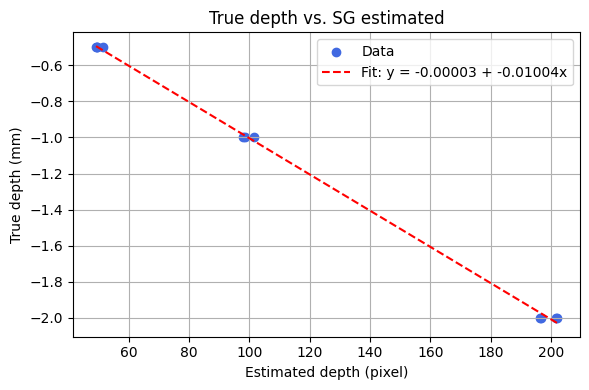

Correlation (depth): -0.99958


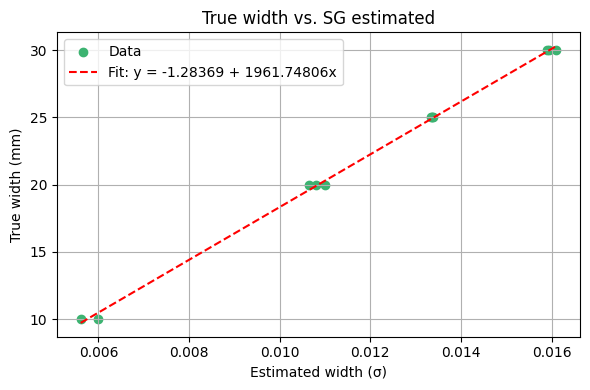

Correlation (width): 0.99934


In [38]:
from numpy.polynomial.polynomial import polyfit
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# Correlación de profundidad A
# ===========================
valid_A = np.isfinite(comparison_df["A_hat"]) & np.isfinite(comparison_df["true_amplitude"])
x_A = comparison_df["A_hat"][valid_A]
y_A = -comparison_df["true_amplitude"][valid_A]  # Usamos el valor absoluto

plt.figure(figsize=(6, 4))
plt.scatter(x_A, y_A, color='royalblue', label="Data")

# Ajuste lineal
b0, b1 = polyfit(x_A, y_A, 1)
x_line = np.linspace(x_A.min(), x_A.max(), 100)
plt.plot(x_line, b0 + b1 * x_line, 'r--', label=f'Fit: y = {b0:.5f} + {b1:.5f}x')

# Límites y etiquetas
plt.xlabel("Estimated depth (pixel)")
plt.ylabel("True depth (mm)")
plt.title("True depth vs. SG estimated")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

if valid_A.sum() >= 2:
    corr_A = np.corrcoef(x_A, y_A)[0, 1]
    print(f"Correlation (depth): {corr_A:.5f}")
else:
    print("Not enough valid data for A correlation.")

# ===========================
# Correlación de anchura σ
# ===========================
valid_sigma = np.isfinite(comparison_df["sigma_hat"]) & np.isfinite(comparison_df["true_sigma"])
x_sigma = comparison_df["sigma_hat"][valid_sigma]
y_sigma = comparison_df["true_sigma"][valid_sigma]

plt.figure(figsize=(6, 4))
plt.scatter(x_sigma, y_sigma, color='mediumseagreen', label="Data")

# Ajuste lineal
b0, b1 = polyfit(x_sigma, y_sigma, 1)
x_line = np.linspace(x_sigma.min(), x_sigma.max(), 100)
plt.plot(x_line, b0 + b1 * x_line, 'r--', label=f'Fit: y = {b0:.5f} + {b1:.5f}x')

# Límites y etiquetas
plt.xlabel("Estimated width (σ)")
plt.ylabel("True width (mm)")
plt.title("True width vs. SG estimated")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

if valid_sigma.sum() >= 2:
    corr_sigma = np.corrcoef(x_sigma, y_sigma)[0, 1]
    print(f"Correlation (width): {corr_sigma:.5f}")
else:
    print("Not enough valid data for σ correlation.")


Experimentamos con distintos tamaños de ventana

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from numpy.polynomial.polynomial import polyfit

# ==========
# Función para estimar A y sigma
# ==========
def estimate_gaussian_params_from_parabola(a, b, c):
    a = np.asarray(a)
    b = np.asarray(b)
    c = np.asarray(c)
    x_v = -b / (2 * a)
    f_v = a * x_v**2 + b * x_v + c
    estimated_A = -f_v
    with np.errstate(divide='ignore', invalid='ignore'):
        estimated_sigma = np.sqrt(estimated_A / (2 * np.abs(a)))
    return estimated_A, estimated_sigma

# ==========
# Parámetros
# ==========
window_lengths = [5,11, 31, 51, 71, 91,111]
defect_coords = np.loadtxt("defectos_simulados/experimento1/defects.txt", comments="#")
if defect_coords.ndim == 1:
    defect_coords = defect_coords[np.newaxis, :]

base_output_dir = "output_exp1_correlations"
os.makedirs(base_output_dir, exist_ok=True)

# ==========
# Loop por ventana
# ==========
for window_length in window_lengths:
    records = []
    print(f"\n== Evaluando correlación para ventana {window_length} ==")

    for idx, (x_px, y_px, true_sigma, true_amplitude) in enumerate(defect_coords):
        x_px, y_px = int(x_px), int(y_px)
        perfil = defects[y_px, :]
        x = np.linspace(0, 1, len(perfil))
        x_target = x[x_px]

        x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x, perfil, window_length=window_length)
        a_vals = np.ravel(a_vals)
        b_vals = np.ravel(b_vals)
        c_vals = np.ravel(c_vals)

        peaks_indices, _ = find_peaks(
            a_vals,
            height=60000, prominence=50,
            distance=100, width=3
        )
        if len(peaks_indices) == 0:
            continue

        x_peaks = x_valid[peaks_indices]
        a_peaks = a_vals[peaks_indices]
        b_peaks = b_vals[peaks_indices]
        c_peaks = c_vals[peaks_indices]
        vertices = x_peaks - b_peaks / (2 * a_peaks)
        idx_closest = np.argmin(np.abs(vertices - x_target))

        a = a_peaks[idx_closest]
        b = b_peaks[idx_closest]
        c = c_peaks[idx_closest]
        vertex = vertices[idx_closest]

        A_hat, sigma_hat = estimate_gaussian_params_from_parabola(a, b, c)

        records.append({
            "defect_idx": idx,
            "true_amplitude": true_amplitude,
            "true_sigma": true_sigma,
            "a_detected": a,
            "b_detected": b,
            "c_detected": c,
            "vertex": vertex,
            "A_hat": A_hat,
            "sigma_hat": sigma_hat
        })

    comparison_df = pd.DataFrame.from_records(records)
    output_dir = os.path.join(base_output_dir, f"window_{window_length}")
    os.makedirs(output_dir, exist_ok=True)

    # ===========================
    # Plot correlación A
    # ===========================
    valid_A = np.isfinite(comparison_df["A_hat"]) & np.isfinite(comparison_df["true_amplitude"])
    x_A = -comparison_df["true_amplitude"][valid_A]
    y_A = comparison_df["A_hat"][valid_A]

    plt.figure(figsize=(6, 4))
    plt.scatter(x_A, y_A, color='royalblue', label="Data")

    if valid_A.sum() >= 2:
        b0, b1 = polyfit(x_A, y_A, 1)
        x_line = np.linspace(x_A.min(), x_A.max(), 100)
        plt.plot(x_line, b0 + b1 * x_line, 'r--', label=f'Fit: y = {b0:.3f} + {b1:.3f}x')
        corr_A = np.corrcoef(x_A, y_A)[0, 1]
        plt.title(f"Depth estimation — corr = {corr_A:.3f}")
    else:
        plt.title("Not enough valid data for A correlation")


    plt.xlabel("True depth (|A|)")
    plt.ylabel("Estimated depth")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "correlation_depth.png"))
    plt.close()

    # ===========================
    # Plot correlación σ
    # ===========================
    valid_sigma = np.isfinite(comparison_df["sigma_hat"]) & np.isfinite(comparison_df["true_sigma"])
    x_sigma = comparison_df["true_sigma"][valid_sigma]
    y_sigma = comparison_df["sigma_hat"][valid_sigma]

    plt.figure(figsize=(6, 4))
    plt.scatter(x_sigma, y_sigma, color='mediumseagreen', label="Data")

    if valid_sigma.sum() >= 2:
        b0, b1 = polyfit(x_sigma, y_sigma, 1)
        x_line = np.linspace(x_sigma.min(), x_sigma.max(), 100)
        plt.plot(x_line, b0 + b1 * x_line, 'r--', label=f'Fit: y = {b0:.3f} + {b1:.3f}x')
        corr_sigma = np.corrcoef(x_sigma, y_sigma)[0, 1]
        plt.title(f"Width estimation — corr = {corr_sigma:.3f}")
    else:
        plt.title("Not enough valid data for σ correlation")


    plt.xlabel("True width (σ)")
    plt.ylabel("Estimated width")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "correlation_width.png"))
    plt.close()

    print(f"Correlaciones guardadas en {output_dir}")
    if valid_A.sum() >= 2:
        print(f"Correlación (depth): {corr_A:.3f}")
    else:
        print("No hay suficientes datos válidos para la correlación de A.")
    if valid_sigma.sum() >= 2:
        print(f"Correlación (width): {corr_sigma:.3f}")
    else:   
        print("No hay suficientes datos válidos para la correlación de σ.")
    print("===================================")



== Evaluando correlación para ventana 5 ==
Correlaciones guardadas en output_exp1_correlations/window_5
Correlación (depth): -0.738
Correlación (width): -0.304

== Evaluando correlación para ventana 11 ==
Correlaciones guardadas en output_exp1_correlations/window_11
Correlación (depth): -0.999
Correlación (width): 0.732

== Evaluando correlación para ventana 31 ==
Correlaciones guardadas en output_exp1_correlations/window_31
Correlación (depth): -1.000
Correlación (width): 0.999

== Evaluando correlación para ventana 51 ==
Correlaciones guardadas en output_exp1_correlations/window_51
Correlación (depth): -0.999
Correlación (width): 0.994

== Evaluando correlación para ventana 71 ==
Correlaciones guardadas en output_exp1_correlations/window_71
Correlación (depth): -0.991
Correlación (width): 0.988

== Evaluando correlación para ventana 91 ==
Correlaciones guardadas en output_exp1_correlations/window_91
Correlación (depth): -0.973
Correlación (width): 0.982

== Evaluando correlación par

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from numpy.polynomial.polynomial import polyfit
import camera.raw as raw


# ==========
# Parámetros de barrido
# ==========
window_lengths = [5, 11, 31, 51, 71, 91, 111]
experimentos = [
    {"path": "defectos_simulados/experimento1", "nombre": "exp1"},
    {"path": "defectos_simulados/experimento2", "nombre": "exp2"}
]

# ==========
# Loop por ventana
# ==========
for window_length in window_lengths:
    all_records = []
    print(f"\n== Evaluando correlación para ventana {window_length} en ambos experimentos ==")

    for exp in experimentos:
        base_path = exp["path"]
        exp_name = exp["nombre"]

        # Cargar imagen y defectos
        dist = raw.read_img_raw(f"{base_path}/escaneo/step_00_orig_perlin.raw")
        dist = dist[:907, 900:3500]
        ground_truth = raw.read_img_raw(f"{base_path}/escaneo_limpio/step_00_orig.raw")
        ground_truth = ground_truth[:907, 900:3500]
        defects = ground_truth - dist

        defect_coords = np.loadtxt(f"{base_path}/defects.txt", comments="#")
        if defect_coords.ndim == 1:
            defect_coords = defect_coords[np.newaxis, :]

        for idx, (x_px, y_px, true_sigma, true_amplitude) in enumerate(defect_coords):
            x_px, y_px = int(x_px), int(y_px)
            perfil = defects[y_px, :]
            x = np.linspace(0, 1, len(perfil))
            x_target = x[x_px]

            x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x, perfil, window_length=window_length)
            a_vals = np.ravel(a_vals)
            b_vals = np.ravel(b_vals)
            c_vals = np.ravel(c_vals)

            peaks_indices, _ = find_peaks(
                a_vals,
                height=60000, prominence=50,
                distance=100, width=3
            )
            if len(peaks_indices) == 0:
                continue

            x_peaks = x_valid[peaks_indices]
            a_peaks = a_vals[peaks_indices]
            b_peaks = b_vals[peaks_indices]
            c_peaks = c_vals[peaks_indices]
            vertices = x_peaks - b_peaks / (2 * a_peaks)

            idx_closest = np.argmin(np.abs(vertices - x_target))

            a = a_peaks[idx_closest]
            b = b_peaks[idx_closest]
            c = c_peaks[idx_closest]
            vertex = vertices[idx_closest]

            A_hat, sigma_hat = estimate_gaussian_params_from_parabola(a, b, c)

            all_records.append({
                "experiment": exp_name,
                "defect_idx": idx,
                "true_amplitude": true_amplitude,
                "true_sigma": true_sigma,
                "a_detected": a,
                "b_detected": b,
                "c_detected": c,
                "vertex": vertex,
                "A_hat": A_hat,
                "sigma_hat": sigma_hat
            })

    comparison_df = pd.DataFrame.from_records(all_records)
    output_dir = os.path.join("output_combined_correlations", f"window_{window_length}")
    os.makedirs(output_dir, exist_ok=True)

    # ===========================
    # Plot correlación A
    # ===========================
    valid_A = np.isfinite(comparison_df["A_hat"]) & np.isfinite(comparison_df["true_amplitude"])
    x_A = comparison_df["A_hat"][valid_A]
    y_A = -comparison_df["true_amplitude"][valid_A]

    plt.figure(figsize=(6, 4))
    plt.scatter(x_A, y_A, color='royalblue', label="Data")

    if valid_A.sum() >= 2:
        b0, b1 = polyfit(x_A, y_A, 1)
        x_line = np.linspace(x_A.min(), x_A.max(), 100)
        plt.plot(x_line, b0 + b1 * x_line, 'r--', label=f'Fit: y = {b0:.4f} + {b1:.4f}x')

    plt.xlabel("Estimated depth (pixel)")
    plt.ylabel("True depth (mm)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "correlation_depth.png"))
    plt.close()

    # ===========================
    # Plot correlación σ
    # ===========================
    valid_sigma = np.isfinite(comparison_df["sigma_hat"]) & np.isfinite(comparison_df["true_sigma"])
    x_sigma = comparison_df["sigma_hat"][valid_sigma]
    y_sigma = comparison_df["true_sigma"][valid_sigma]

    plt.figure(figsize=(6, 4))
    plt.scatter(x_sigma, y_sigma, color='mediumseagreen', label="Data")

    if valid_sigma.sum() >= 2:
        b0, b1 = polyfit(x_sigma, y_sigma, 1)
        x_line = np.linspace(x_sigma.min(), x_sigma.max(), 100)
        plt.plot(x_line, b0 + b1 * x_line, 'r--', label=f'Fit: y = {b0:.4f} + {b1:.4f}x')

    plt.xlabel("Estimated width (σ)")
    plt.ylabel("True width (mm)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "correlation_width.png"))
    plt.close()

    print(f"Correlaciones combinadas guardadas en {output_dir}")
    if valid_A.sum() >= 2:
        print(f"Correlación (depth): {corr_A:.3f}")
    if valid_sigma.sum() >= 2:
        print(f"Correlación (width): {corr_sigma:.3f}")
    print("===================================")



== Evaluando correlación para ventana 5 en ambos experimentos ==
Correlaciones combinadas guardadas en output_combined_correlations/window_5
Correlación (depth): -0.912
Correlación (width): 0.982

== Evaluando correlación para ventana 11 en ambos experimentos ==
Correlaciones combinadas guardadas en output_combined_correlations/window_11
Correlación (depth): -0.912
Correlación (width): 0.982

== Evaluando correlación para ventana 31 en ambos experimentos ==
Correlaciones combinadas guardadas en output_combined_correlations/window_31
Correlación (depth): -0.912
Correlación (width): 0.982

== Evaluando correlación para ventana 51 en ambos experimentos ==
Correlaciones combinadas guardadas en output_combined_correlations/window_51
Correlación (depth): -0.912
Correlación (width): 0.982

== Evaluando correlación para ventana 71 en ambos experimentos ==
Correlaciones combinadas guardadas en output_combined_correlations/window_71
Correlación (depth): -0.912
Correlación (width): 0.982

== Eva